In [13]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

### CREATING A DATASET

here we are creating a dataset where we are first generating random values of shape(100,1) and then we are using these x values to create a line or an equation i.e. y using the x values

Text(0, 0.5, 'Y dataset')

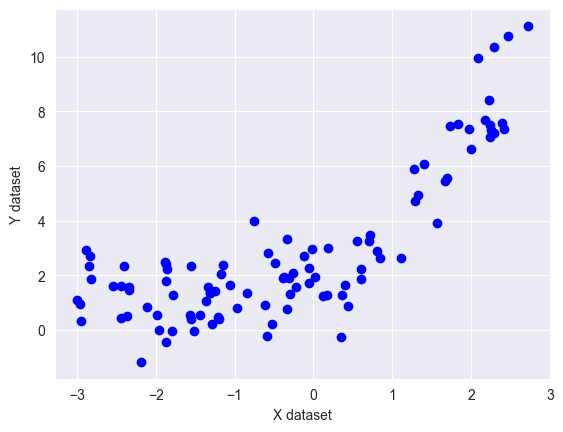

In [27]:
X = 6 * np.random.rand(100, 1) - 3
y =0.5 * X**2 + 1.5*X + 2 + np.random.randn(100, 1)
# quadratic equation used- y=0.5x^2+1.5x+2+outliers
plt.scatter(X,y,color='b')
plt.xlabel('X dataset')
plt.ylabel('Y dataset')

In [28]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [29]:
reg = LinearRegression()


In [30]:
reg.fit(X_train,y_train)

LinearRegression()

In [31]:
prediction = reg.predict(X_test)

After prediction we will check the R2 score . The value of R2 should be near to 1 for the model to be good .

In [32]:
r2 = r2_score(y_test,prediction)
r2

0.575485574165154

### Visualizing the Simple Linear Regression Model

As we can see the value of R2 is very less that is around 0.5 . Now to visualize how our linear reg model looks like right now we are going to plot the line and also we will scatter the y points .

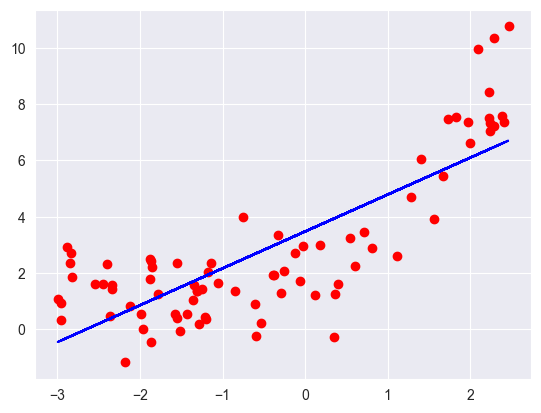

In [35]:
plt.plot(X_train,reg.predict(X_train),color='b')
plt.scatter(X_train,y_train,color='r')


In [36]:
from sklearn.preprocessing import PolynomialFeatures

In [54]:
poly = PolynomialFeatures(degree=4,include_bias=True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [55]:
X_train_poly

# here we got the new values 1 , X , X^2

array([[ 1.00000000e+00, -1.05466544e+00,  1.11231918e+00,
        -1.17312460e+00,  1.23725396e+00],
       [ 1.00000000e+00, -1.31094036e+00,  1.71856463e+00,
        -2.25293574e+00,  2.95346440e+00],
       [ 1.00000000e+00, -1.21639171e+00,  1.47960879e+00,
        -1.79978386e+00,  2.18924217e+00],
       [ 1.00000000e+00, -8.46600451e-01,  7.16732324e-01,
        -6.06785909e-01,  5.13705225e-01],
       [ 1.00000000e+00,  2.28645347e+00,  5.22786946e+00,
         1.19532802e+01,  2.73306191e+01],
       [ 1.00000000e+00,  4.03605641e-01,  1.62897514e-01,
         6.57463556e-02,  2.65356000e-02],
       [ 1.00000000e+00, -1.87123590e+00,  3.50152378e+00,
        -6.55217700e+00,  1.22606688e+01],
       [ 1.00000000e+00, -2.95163899e+00,  8.71217271e+00,
        -2.57151886e+01,  7.59019533e+01],
       [ 1.00000000e+00,  1.56201204e+00,  2.43988161e+00,
         3.81112444e+00,  5.95302226e+00],
       [ 1.00000000e+00, -1.34313264e+00,  1.80400528e+00,
        -2.42301838e+00

In [56]:
reg.fit(X_train_poly,y_train)
y_pred = reg.predict(X_test_poly)
r2_score(y_test,y_pred)

0.9063506371390136

In [57]:
reg.coef_

array([[0.        , 1.17815002, 0.55073023, 0.06947124, 0.00273981]])

In [58]:
reg.intercept_

array([1.8790576])

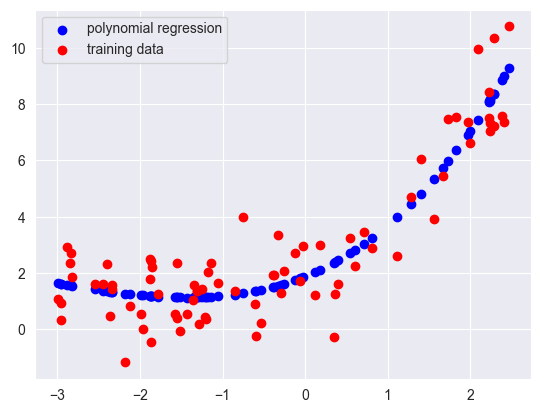

In [61]:
plt.scatter(X_train,reg.predict(X_train_poly),color='b',label='polynomial regression')
plt.scatter(X_train,y_train,color='r',label='training data')
plt.legend()

### PIPELINE CONCEPTS

Pipleine helps us to create a generic function that we can use to simplify our process . Here we have used the pipeline to make a function where we just need to pass the degree and then on the basis of the degree it will plot a graph which will show the polynomial regression line that was made using that degree and the initial points .

This will help us in visualizing and also help us in understanding how different value of degrees have different affects on the model .

In [62]:
from sklearn.pipeline import Pipeline

In [63]:
def poly_regression(degree):
    X_new = np.linspace(-3, 3, 200).reshape(200, 1)

    poly_features=PolynomialFeatures(degree=degree,include_bias=True)
    lin_reg=LinearRegression()
    poly_regression=Pipeline([
        ("poly_features",poly_features),
        ("lin_reg",lin_reg)
    ])
    poly_regression.fit(X_train,y_train) ## ploynomial and fit of linear reression
    y_pred_new=poly_regression.predict(X_new)
    #plotting prediction line
    plt.plot(X_new, y_pred_new,'r', label="Degree " + str(degree), linewidth=2)
    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-4,4, 0, 10])
    plt.show()

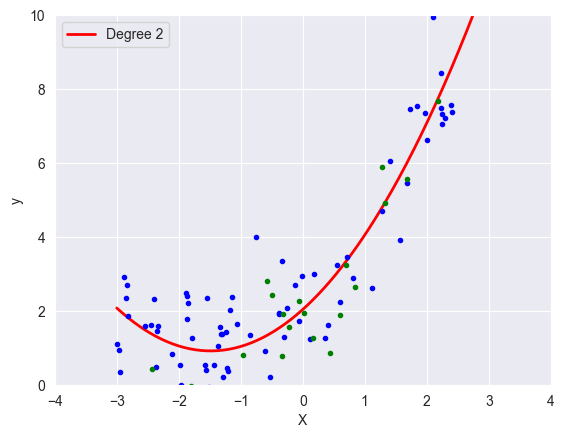

In [64]:
poly_regression(2)

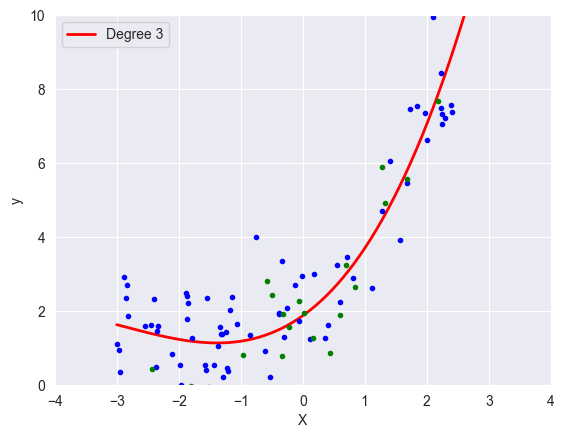

In [65]:
poly_regression(3)

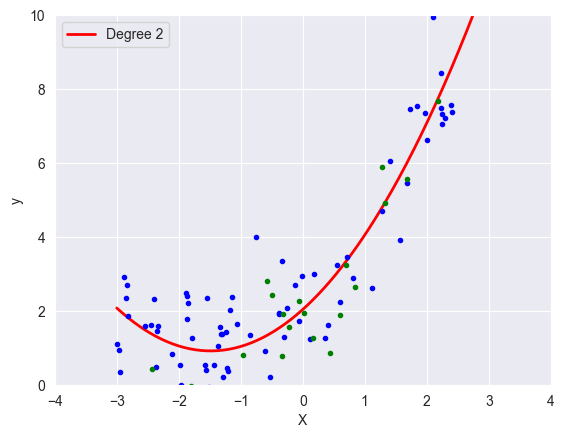

In [72]:
poly_regression(2)